### Tables and Graph EDA
#### Elizabeth Greenan

In [76]:
# Import packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import openpyxl
import os
from tableone import TableOne
from tabulate import tabulate
import scipy.stats as stats

In [77]:
# Read in Excel file 
#e_cigarette_data = pd.read_excel("data/cleaned_data.xlsx")

In [78]:
# Convert Excel file to CSV
#e_cigarette_data.to_csv("cleaned_data.csv", index=False)

In [79]:
e_cigarette_data = pd.read_csv("../Data/cleaned_data.csv")
e_cigarette_data.head()

,Unnamed: 0,BMI,Number_of_Children,Dentist_Visit_Last_Year,Health_Insurance,Lung_Cancer_Suspected_Risk,Marijuana_Use_30_Days,Medical_Visit_Missed_Due_to_Cost,Number_of_Days_Last_Month_Poor_Health,High_Financial_Stress_Burden,...,Health_Rating,Annual_Income,Days_Poor_Physical_Health,Education,Social_Emotional_Support,General_Health_Personal_Rating,Life_Satisfaction,Marital_Status,Sugar_Soda_Drinks_Per_Day,Non_Soda_Sugar_Drinks_Per_Day
0,0,22.49,0.0,1.0,1.0,NaN,NaN,0.0,0.0,0.0,...,Good_or_Better_Health,Unknown,1-13_Days,Grade_12_or_GED_(high_school_graduate,Always,Good,Very_satisfied,Widowed,NaN,NaN
1,1,25.83,0.0,1.0,1.0,NaN,NaN,0.0,NaN,0.0,...,Good_or_Better_Health,"$200,000+",0_Days,College_4_years_or_more_(college_graduate),Always,Excellent,Very_satisfied,Married,NaN,NaN
2,2,22.53,0.0,0.0,1.0,NaN,NaN,1.0,1.0,0.0,...,Good_or_Better_Health,Unknown,14+_Days,College_1-3_years_(some_college_or_technical_s...,Usually,Very_good,Very_satisfied,Member_of_unmarried_couple,NaN,NaN
3,3,25.09,0.0,1.0,1.0,NaN,NaN,0.0,NaN,0.0,...,Good_or_Better_Health,"Less_than_$50,000",0_Days,College_4_years_or_more_(college_graduate),Always,Excellent,Very_satisfied,Married,NaN,NaN
4,4,19.77,0.0,1.0,1.0,0.0,NaN,0.0,NaN,0.0,...,Good_or_Better_Health,"Less_than_$20,000",0_Days,College_1-3_years_(some_college_or_technical_s...,Rarely,Good,Satisfied,Never_Married,NaN,NaN


In [80]:
# Original BMI variable EDA has been commented out since it is not needed anymore
# Look at BMI when not divided by 100 to see distribution
#e_cigarette_data['BMI_raw'] = e_cigarette_data['BMI'] * 100

In [81]:
#print(e_cigarette_data['BMI_raw'].unique())

In [82]:
#print(e_cigarette_data['BMI_raw'].min())

In [83]:
#print(e_cigarette_data['BMI_raw'].max())

In [84]:
# Calculate statistics on raw BMI variable
#e_cigarette_data.groupby('E_Cig_User')['BMI_raw'].describe()

In [85]:
# Calculate statistics on altered BMI variable that was divided by 100
e_cigarette_data.groupby('E_Cig_User')['BMI'].describe()

,count,mean,std,min,25%,50%,75%,max
E_Cig_User,,,,,,,,
0.0,375109.0,28.575102,6.473604,12.0,24.21,27.44,31.75,76.86
1.0,23546.0,28.279965,7.054482,12.4,23.30,27.12,31.89,75.58


In [86]:
e_cigarette_data['BMI'].isna().sum()

43170

In [87]:
# Look at underweight individuals with a BMI < 20 to see if there are many outliers
underweight = e_cigarette_data[e_cigarette_data['BMI'] < 20]
underweight['E_Cig_User'].value_counts()

E_Cig_User
0.0    16858
1.0     1738
Name: count, dtype: int64

In [88]:
# Total number of underweight individuals with a BMI < 20
len(underweight)

19478

In [89]:
# Determine the split between e-cigarette users and non e-cigarette users with low BMI
e_cigarette_data[e_cigarette_data['BMI'] < 20].groupby('E_Cig_User').size()

E_Cig_User
0.0    16858
1.0     1738
dtype: int64

In [90]:
# Look at overweight individuals with a BMI > 90 to see if there are many outliers
#overweight = e_cigarette_data[e_cigarette_data['BMI'] > 90]
#overweight['E_Cig_User'].value_counts()

In [91]:
# Total number of overweight individuals with a BMI > 90
#len(overweight)

In [92]:
# Determine the split between e-cigarette users and non e-cigarette users with high BMI
#e_cigarette_data[e_cigarette_data['BMI'] > 90].groupby('E_Cig_User').size()

In [93]:
# Drop BMI_raw variable from dataset since it is not needed
#e_cigarette_data.drop(columns=['BMI_raw'], inplace = True)

In [94]:
e_cigarette_data.columns.unique()

Index(['Unnamed: 0', 'BMI', 'Number_of_Children', 'Dentist_Visit_Last_Year',
       'Health_Insurance', 'Lung_Cancer_Suspected_Risk',
       'Marijuana_Use_30_Days', 'Medical_Visit_Missed_Due_to_Cost',
       'Number_of_Days_Last_Month_Poor_Health', 'High_Financial_Stress_Burden',
       'Sex', 'Has_Disability', 'Diabetic_History', 'Days_Poor_Mental_Health',
       'Age_Category', 'E_Cig_User', 'Other_Tobacco_Usage', 'Race',
       'Total_Drinks_30_days', 'Time_Since_Last_Check_Up',
       'Exercise_Outside_Work_Past_Month', 'Loneliness', 'Health_Rating',
       'Annual_Income', 'Days_Poor_Physical_Health', 'Education',
       'Social_Emotional_Support', 'General_Health_Personal_Rating',
       'Life_Satisfaction', 'Marital_Status', 'Sugar_Soda_Drinks_Per_Day',
       'Non_Soda_Sugar_Drinks_Per_Day'],
      dtype='object')

In [96]:
# Remove the Unnamed: 0 field that appeared when I converted from .XLSX to .CSV
e_cigarette_data = e_cigarette_data.drop(columns=['Unnamed: 0'])

In [97]:
e_cigarette_data.head()

,BMI,Number_of_Children,Dentist_Visit_Last_Year,Health_Insurance,Lung_Cancer_Suspected_Risk,Marijuana_Use_30_Days,Medical_Visit_Missed_Due_to_Cost,Number_of_Days_Last_Month_Poor_Health,High_Financial_Stress_Burden,Sex,...,Health_Rating,Annual_Income,Days_Poor_Physical_Health,Education,Social_Emotional_Support,General_Health_Personal_Rating,Life_Satisfaction,Marital_Status,Sugar_Soda_Drinks_Per_Day,Non_Soda_Sugar_Drinks_Per_Day
0,22.49,0.0,1.0,1.0,NaN,NaN,0.0,0.0,0.0,Female,...,Good_or_Better_Health,Unknown,1-13_Days,Grade_12_or_GED_(high_school_graduate,Always,Good,Very_satisfied,Widowed,NaN,NaN
1,25.83,0.0,1.0,1.0,NaN,NaN,0.0,NaN,0.0,Male,...,Good_or_Better_Health,"$200,000+",0_Days,College_4_years_or_more_(college_graduate),Always,Excellent,Very_satisfied,Married,NaN,NaN
2,22.53,0.0,0.0,1.0,NaN,NaN,1.0,1.0,0.0,Male,...,Good_or_Better_Health,Unknown,14+_Days,College_1-3_years_(some_college_or_technical_s...,Usually,Very_good,Very_satisfied,Member_of_unmarried_couple,NaN,NaN
3,25.09,0.0,1.0,1.0,NaN,NaN,0.0,NaN,0.0,Male,...,Good_or_Better_Health,"Less_than_$50,000",0_Days,College_4_years_or_more_(college_graduate),Always,Excellent,Very_satisfied,Married,NaN,NaN
4,19.77,0.0,1.0,1.0,0.0,NaN,0.0,NaN,0.0,Male,...,Good_or_Better_Health,"Less_than_$20,000",0_Days,College_1-3_years_(some_college_or_technical_s...,Rarely,Good,Satisfied,Never_Married,NaN,NaN


In [98]:
e_cigarette_data.columns.unique()

Index(['BMI', 'Number_of_Children', 'Dentist_Visit_Last_Year',
       'Health_Insurance', 'Lung_Cancer_Suspected_Risk',
       'Marijuana_Use_30_Days', 'Medical_Visit_Missed_Due_to_Cost',
       'Number_of_Days_Last_Month_Poor_Health', 'High_Financial_Stress_Burden',
       'Sex', 'Has_Disability', 'Diabetic_History', 'Days_Poor_Mental_Health',
       'Age_Category', 'E_Cig_User', 'Other_Tobacco_Usage', 'Race',
       'Total_Drinks_30_days', 'Time_Since_Last_Check_Up',
       'Exercise_Outside_Work_Past_Month', 'Loneliness', 'Health_Rating',
       'Annual_Income', 'Days_Poor_Physical_Health', 'Education',
       'Social_Emotional_Support', 'General_Health_Personal_Rating',
       'Life_Satisfaction', 'Marital_Status', 'Sugar_Soda_Drinks_Per_Day',
       'Non_Soda_Sugar_Drinks_Per_Day'],
      dtype='object')

In [99]:
e_cigarette_data.dtypes

BMI                                      float64
Number_of_Children                       float64
Dentist_Visit_Last_Year                  float64
Health_Insurance                         float64
Lung_Cancer_Suspected_Risk               float64
Marijuana_Use_30_Days                    float64
Medical_Visit_Missed_Due_to_Cost         float64
Number_of_Days_Last_Month_Poor_Health    float64
High_Financial_Stress_Burden             float64
Sex                                       object
Has_Disability                           float64
Diabetic_History                         float64
Days_Poor_Mental_Health                   object
Age_Category                              object
E_Cig_User                               float64
Other_Tobacco_Usage                       object
Race                                      object
Total_Drinks_30_days                     float64
Time_Since_Last_Check_Up                  object
Exercise_Outside_Work_Past_Month         float64
Loneliness          

In [100]:
# Basic EDA looking at unique values for multiple variables

In [101]:
print(e_cigarette_data['Non_Soda_Sugar_Drinks_Per_Day'].unique())

[nan  1.  2.  3. 20. 12.  6.  5.  7.  4. 31. 14. 30. 10. 99. 15.  9.  8.
 50. 28. 25. 53. 24. 22. 13. 18. 40. 16.]


In [102]:
print(e_cigarette_data['Marijuana_Use_30_Days'].unique())

[nan  0. 30. 25.  1. 20.  5. 15.  3. 27.  2. 26. 29. 10.  8.  4.  7.  6.
 28. 16. 18. 12.  9. 14. 23. 21. 13. 24. 11. 22. 17. 19.]


In [103]:
print(e_cigarette_data['BMI'].unique())

[22.49 25.83 22.53 ... 42.46 45.95 40.65]


In [104]:
print(e_cigarette_data['Sugar_Soda_Drinks_Per_Day'].unique())

[nan  1.  3.  2.  5.  4.  7. 91. 20.  6. 12. 30. 10.  8. 96. 31. 99. 15.
 21. 50. 24. 29.  9. 18. 16. 70. 23. 22. 25. 11. 13. 14. 33. 41. 17. 98.]


In [105]:
# Create lists for both categorical and continuous variables so their tables can be created

In [106]:
categorical_var = ['Dentist_Visit_Last_Year', 'Health_Insurance', 'Lung_Cancer_Suspected_Risk', 'Medical_Visit_Missed_Due_to_Cost', 'High_Financial_Stress_Burden', 'Sex', 'Has_Disability', 'Diabetic_History', 'Days_Poor_Mental_Health', 'Age_Category', 'Other_Tobacco_Usage', 'Race', 'Time_Since_Last_Check_Up', 'Exercise_Outside_Work_Past_Month', 'Loneliness', 'Health_Rating', 'Annual_Income', 'Days_Poor_Physical_Health', 'Education', 'Social_Emotional_Support', 'General_Health_Personal_Rating', 'Life_Satisfaction', 'Marital_Status', 'E_Cig_User']

In [107]:
continuous_var = ['BMI', 'Number_of_Children', 'Marijuana_Use_30_Days', 'Number_of_Days_Last_Month_Poor_Health', 'Total_Drinks_30_days', 'Sugar_Soda_Drinks_Per_Day', 'Non_Soda_Sugar_Drinks_Per_Day']

In [108]:
print(categorical_var)

['Dentist_Visit_Last_Year', 'Health_Insurance', 'Lung_Cancer_Suspected_Risk', 'Medical_Visit_Missed_Due_to_Cost', 'High_Financial_Stress_Burden', 'Sex', 'Has_Disability', 'Diabetic_History', 'Days_Poor_Mental_Health', 'Age_Category', 'Other_Tobacco_Usage', 'Race', 'Time_Since_Last_Check_Up', 'Exercise_Outside_Work_Past_Month', 'Loneliness', 'Health_Rating', 'Annual_Income', 'Days_Poor_Physical_Health', 'Education', 'Social_Emotional_Support', 'General_Health_Personal_Rating', 'Life_Satisfaction', 'Marital_Status', 'E_Cig_User']


In [109]:
print(continuous_var)

['BMI', 'Number_of_Children', 'Marijuana_Use_30_Days', 'Number_of_Days_Last_Month_Poor_Health', 'Total_Drinks_30_days', 'Sugar_Soda_Drinks_Per_Day', 'Non_Soda_Sugar_Drinks_Per_Day']


In [110]:
# Create categorical variable table

In [111]:
# Create an empty list
combined_categorical_tables = []

# Create a table that includes Variable, Value, Count, and Percent
for col in categorical_var:
    counts = e_cigarette_data[col].value_counts(dropna = False) # Including NaN values for now
    percent = e_cigarette_data[col].value_counts(normalize = True, dropna = False) * 100 # Multiply by 100 to print as a percentage
    table = pd.DataFrame({'Variable': col,
                          'Value': counts.index,
                          'Count': counts.values,
                          'Percent': percent.values})
    combined_categorical_tables.append(table) # Append to the empty list

# Combine individual tables into a final summary table
final_categorical_table = pd.concat(combined_categorical_tables, ignore_index = True)

# Round the percent column to two decimal places (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.round.html)
final_categorical_table['Percent'] = final_categorical_table['Percent'].round(2)

# Add comma to the count field for readability
# https://stackoverflow.com/questions/57677439/insert-comma-in-numeric-columns-of-a-pandas-dataframe#:~:text=Insert%20comma%20in%20numeric%20columns%20of%20a%20pandas%20dataframe%20python%2D3.%20x%20pandas%20dataframe
# https://www.markhneedham.com/blog/2021/04/11/pandas-format-dataframe-numbers-commas-decimals/
final_categorical_table['Count'] = final_categorical_table['Count'].map("{:,d}".format)

#https://pypi.org/project/tabulate/
# Headers = keys uses the column names as headers
print(tabulate(final_categorical_table, headers = 'keys', tablefmt = 'fancy_grid', showindex = False))

╒══════════════════════════════════╤═════════════════════════════════════════════════════╤═════════╤═══════════╕
│ Variable                         │ Value                                               │   Count │   Percent │
╞══════════════════════════════════╪═════════════════════════════════════════════════════╪═════════╪═══════════╡
│ Dentist_Visit_Last_Year          │ 1.0                                                 │ 311,259 │     68.01 │
├──────────────────────────────────┼─────────────────────────────────────────────────────┼─────────┼───────────┤
│ Dentist_Visit_Last_Year          │ 0.0                                                 │ 140,705 │     30.74 │
├──────────────────────────────────┼─────────────────────────────────────────────────────┼─────────┼───────────┤
│ Dentist_Visit_Last_Year          │ nan                                                 │   5,706 │      1.25 │
├──────────────────────────────────┼─────────────────────────────────────────────────────┼──────

In [142]:
# print final table as a CSV file
final_categorical_table.to_csv("../Tables/categorical_variables_summary.csv", index = False)

In [113]:
# Create table for all of the NaN values from the above table to clearly show missingness among variables

In [114]:
# Create an empty list
missing_table_cat = []

for col in categorical_var:
    total_length = len(e_cigarette_data[col])
    missing_count = e_cigarette_data[col].isna().sum()
    missing_percent = (missing_count / total_length) * 100

    table = pd.DataFrame({
        'Variable': [col],
        'Missing Count': [missing_count],
        'Missing Percent': [missing_percent]})
    missing_table_cat.append(table)

categorical_missing_table = pd.concat(missing_table_cat, ignore_index=True)

categorical_missing_table['Missing Percent'] = categorical_missing_table['Missing Percent'].round(2)

categorical_missing_table['Missing Count'] = categorical_missing_table['Missing Count'].map("{:,d}".format)

print(tabulate(categorical_missing_table, headers = 'keys', tablefmt = 'fancy_grid', showindex = False))

╒══════════════════════════════════╤═════════════════╤═══════════════════╕
│ Variable                         │   Missing Count │   Missing Percent │
╞══════════════════════════════════╪═════════════════╪═══════════════════╡
│ Dentist_Visit_Last_Year          │           5,706 │              1.25 │
├──────────────────────────────────┼─────────────────┼───────────────────┤
│ Health_Insurance                 │          18,544 │              4.05 │
├──────────────────────────────────┼─────────────────┼───────────────────┤
│ Lung_Cancer_Suspected_Risk       │         285,111 │             62.3  │
├──────────────────────────────────┼─────────────────┼───────────────────┤
│ Medical_Visit_Missed_Due_to_Cost │           1,673 │              0.37 │
├──────────────────────────────────┼─────────────────┼───────────────────┤
│ High_Financial_Stress_Burden     │         256,223 │             55.98 │
├──────────────────────────────────┼─────────────────┼───────────────────┤
│ Sex                    

In [115]:
# print final missingness table as a CSV file
categorical_missing_table.to_csv("../Tables/categorical_missing_variables_summary.csv", index = False)

In [116]:
# Create table for all of the Unknown values from the above table to clearly show missingness among variables

In [117]:
# Create an empty list
unknown_table_cat = []

for col in categorical_var:
    total_length = len(e_cigarette_data[col])
    unknown_count = (e_cigarette_data[col]=='Unknown').sum()
    unknown_percent = (unknown_count / total_length) * 100

    table = pd.DataFrame({
        'Variable': [col],
        'Unknown Count': [unknown_count],
        'Unknown Percent': [unknown_percent]})
    unknown_table_cat.append(table)

categorical_unknown_table = pd.concat(unknown_table_cat, ignore_index=True)

categorical_unknown_table['Unknown Percent'] = categorical_unknown_table['Unknown Percent'].round(2)

categorical_unknown_table['Unknown Count'] = categorical_unknown_table['Unknown Count'].map("{:,d}".format)

print(tabulate(categorical_unknown_table, headers = 'keys', tablefmt = 'fancy_grid', showindex = False))

╒══════════════════════════════════╤═════════════════╤═══════════════════╕
│ Variable                         │   Unknown Count │   Unknown Percent │
╞══════════════════════════════════╪═════════════════╪═══════════════════╡
│ Dentist_Visit_Last_Year          │               0 │              0    │
├──────────────────────────────────┼─────────────────┼───────────────────┤
│ Health_Insurance                 │               0 │              0    │
├──────────────────────────────────┼─────────────────┼───────────────────┤
│ Lung_Cancer_Suspected_Risk       │               0 │              0    │
├──────────────────────────────────┼─────────────────┼───────────────────┤
│ Medical_Visit_Missed_Due_to_Cost │               0 │              0    │
├──────────────────────────────────┼─────────────────┼───────────────────┤
│ High_Financial_Stress_Burden     │               0 │              0    │
├──────────────────────────────────┼─────────────────┼───────────────────┤
│ Sex                    

In [118]:
# print final unknown table as a CSV file
categorical_unknown_table.to_csv("../Tables/categorical_unknown_variables_summary.csv", index = False)

In [119]:
# Create continuous variable table

In [120]:
# Create an empty list
combined_continuous_tables = []

# Create summary table that includes statistics
for col in continuous_var:
    series = e_cigarette_data[col].dropna() # Drop NA values for continuous variable statistics
    n = series.count()
    mean = series.mean()
    std = series.std()
    median = series.median()
    se = std / np.sqrt(n)
    ci_lower = mean - 1.96 * se
    ci_upper = mean + 1.96 * se
    min_value = series.min()
    max_value = series.max()
    skew = series.skew()
    kurtosis = series.kurtosis()
    
    table = pd.DataFrame({'Variable': col,
                          'Count': [n],
                          'Mean': [mean],
                          'St. Dev.': [std],
                          'Median': [median],
                          '95% CI Lower': [ci_lower],
                          '95% CI Upper': [ci_upper],
                          'Min': [min_value],
                          'Max': [max_value],
                          'Skew': [skew],
                          'Kurtosis': [kurtosis]})
    combined_continuous_tables.append(table)

# Combine individual tables
final_continuous_table = pd.concat(combined_continuous_tables, ignore_index = True)

# Round numeric values
final_continuous_table = final_continuous_table.round({
    'Mean': 2,
    'St. Dev.': 2,
    'Median': 2,
    '95% CI Lower': 2,
    '95% CI Upper': 2,
    'Min': 2,
    'Max': 2,
    'Skew': 2,
    'Kurtosis': 2})

# Add commas to the count field
final_continuous_table['Count'] = final_continuous_table['Count'].map("{:,d}".format)

print(tabulate(final_continuous_table, headers = 'keys', tablefmt = 'fancy_grid', showindex = False))

╒═══════════════════════════════════════╤═════════╤════════╤════════════╤══════════╤════════════════╤════════════════╤═══════╤═════════╤════════╤════════════╕
│ Variable                              │   Count │   Mean │   St. Dev. │   Median │   95% CI Lower │   95% CI Upper │   Min │     Max │   Skew │   Kurtosis │
╞═══════════════════════════════════════╪═════════╪════════╪════════════╪══════════╪════════════════╪════════════════╪═══════╪═════════╪════════╪════════════╡
│ BMI                                   │ 414,500 │  28.54 │       6.51 │    27.44 │          28.52 │          28.56 │    12 │   76.86 │   1.27 │       3.21 │
├───────────────────────────────────────┼─────────┼────────┼────────────┼──────────┼────────────────┼────────────────┼───────┼─────────┼────────┼────────────┤
│ Number_of_Children                    │ 448,291 │   0.48 │       1.14 │     0    │           0.48 │           0.49 │     0 │   83    │  16.75 │    1028.58 │
├───────────────────────────────────────┼─────

In [121]:
# Print table as a CSV file
final_continuous_table.to_csv("../Tables/continuous_variables_summary.csv", index = False)

In [122]:
# Create table for all of the NaN values from the above table to clearly show missingness among variables

In [123]:
# Create an empty list
missing_table_cont = []

for col in continuous_var:
    total_length = len(e_cigarette_data[col])
    missing_count = e_cigarette_data[col].isna().sum()
    missing_percent = (missing_count / total_length) * 100

    table = pd.DataFrame({
        'Variable': [col],
        'Missing Count': [missing_count],
        'Missing Percent': [missing_percent]})
    missing_table_cont.append(table)

continuous_missing_table = pd.concat(missing_table_cont, ignore_index=True)

continuous_missing_table['Missing Percent'] = continuous_missing_table['Missing Percent'].round(2)

continuous_missing_table['Missing Count'] = continuous_missing_table['Missing Count'].map("{:,d}".format)

print(tabulate(continuous_missing_table, headers = 'keys', tablefmt = 'fancy_grid', showindex = False))

╒═══════════════════════════════════════╤═════════════════╤═══════════════════╕
│ Variable                              │   Missing Count │   Missing Percent │
╞═══════════════════════════════════════╪═════════════════╪═══════════════════╡
│ BMI                                   │          43,170 │              9.43 │
├───────────────────────────────────────┼─────────────────┼───────────────────┤
│ Number_of_Children                    │           9,379 │              2.05 │
├───────────────────────────────────────┼─────────────────┼───────────────────┤
│ Marijuana_Use_30_Days                 │         321,789 │             70.31 │
├───────────────────────────────────────┼─────────────────┼───────────────────┤
│ Number_of_Days_Last_Month_Poor_Health │         195,028 │             42.61 │
├───────────────────────────────────────┼─────────────────┼───────────────────┤
│ Total_Drinks_30_days                  │         249,959 │             54.62 │
├───────────────────────────────────────

In [124]:
# Confirm that the high missing percentage is correct
e_cigarette_data['Non_Soda_Sugar_Drinks_Per_Day'].isna().sum()

445447

In [125]:
# print final missingness table as a CSV file
continuous_missing_table.to_csv("../Tables/continuous_missing_variables_summary.csv", index = False)

In [126]:
# Create table for all of the Unknown values from the continuous variable table to clearly show missingness among variables

In [127]:
# Create an empty list
unknown_table_cont = []

for col in continuous_var:
    total_length = len(e_cigarette_data[col])
    unknown_count = (e_cigarette_data[col]=='Unknown').sum()
    unknown_percent = (unknown_count / total_length) * 100

    table = pd.DataFrame({
        'Variable': [col],
        'Unknown Count': [unknown_count],
        'Unknown Percent': [unknown_percent]})
    unknown_table_cont.append(table)

continuous_unknown_table = pd.concat(unknown_table_cont, ignore_index=True)

continuous_unknown_table['Unknown Percent'] = continuous_unknown_table['Unknown Percent'].round(2)

continuous_unknown_table['Unknown Count'] = continuous_unknown_table['Unknown Count'].map("{:,d}".format)

print(tabulate(continuous_unknown_table, headers = 'keys', tablefmt = 'fancy_grid', showindex = False))

╒═══════════════════════════════════════╤═════════════════╤═══════════════════╕
│ Variable                              │   Unknown Count │   Unknown Percent │
╞═══════════════════════════════════════╪═════════════════╪═══════════════════╡
│ BMI                                   │               0 │                 0 │
├───────────────────────────────────────┼─────────────────┼───────────────────┤
│ Number_of_Children                    │               0 │                 0 │
├───────────────────────────────────────┼─────────────────┼───────────────────┤
│ Marijuana_Use_30_Days                 │               0 │                 0 │
├───────────────────────────────────────┼─────────────────┼───────────────────┤
│ Number_of_Days_Last_Month_Poor_Health │               0 │                 0 │
├───────────────────────────────────────┼─────────────────┼───────────────────┤
│ Total_Drinks_30_days                  │               0 │                 0 │
├───────────────────────────────────────

In [128]:
# Summary of continuous variables by outcome classes

In [129]:
# Create an empty list
continuous_var_by_outcome_class = []

for col in continuous_var:
    for outcome_class, group in e_cigarette_data.groupby('E_Cig_User', dropna = False): # E_Cig_User is the outcome class
        series = group[col].dropna() # Drop NA values for continuous variable statistics
        n = series.count()
        mean = series.mean()
        std = series.std()
        median = series.median()
        se = std / np.sqrt(n)
        ci_lower = mean - 1.96 * se
        ci_upper = mean + 1.96 * se
        min_value = series.min()
        max_value = series.max()
        skew = series.skew()
        kurtosis = series.kurtosis()
    
        table = pd.DataFrame({'Variable': col,
                              'Outcome Class': outcome_class,
                              'Count': [n],
                              'Mean': [mean],
                              'St. Dev.': [std],
                              'Median': [median],
                              '95% CI Lower': [ci_lower],
                              '95% CI Upper': [ci_upper],
                              'Min': [min_value],
                              'Max': [max_value],
                              'Skew': [skew],
                              'Kurtosis': [kurtosis]})

        continuous_var_by_outcome_class.append(table)

# Combine individual tables
continuous_table_by_outcome = pd.concat(continuous_var_by_outcome_class, ignore_index = True)

# Round numeric values
continuous_table_by_outcome = continuous_table_by_outcome.round({
    'Mean': 2,
    'St. Dev.': 2,
    'Median': 2,
    '95% CI Lower': 2,
    '95% CI Upper': 2,
    'Min': 2,
    'Max': 2,
    'Skew': 2,
    'Kurtosis': 2})

# Add commas to the count field
continuous_table_by_outcome['Count'] = continuous_table_by_outcome['Count'].map("{:,d}".format)

print(tabulate(continuous_table_by_outcome, headers = 'keys', tablefmt = 'fancy_grid', showindex = False))

╒═══════════════════════════════════════╤═════════════════╤═════════╤════════╤════════════╤══════════╤════════════════╤════════════════╤═══════╤═════════╤════════╤════════════╕
│ Variable                              │   Outcome Class │   Count │   Mean │   St. Dev. │   Median │   95% CI Lower │   95% CI Upper │   Min │     Max │   Skew │   Kurtosis │
╞═══════════════════════════════════════╪═════════════════╪═════════╪════════╪════════════╪══════════╪════════════════╪════════════════╪═══════╪═════════╪════════╪════════════╡
│ BMI                                   │               0 │ 375,109 │  28.58 │       6.47 │    27.44 │          28.55 │          28.6  │ 12    │   76.86 │   1.27 │       3.22 │
├───────────────────────────────────────┼─────────────────┼─────────┼────────┼────────────┼──────────┼────────────────┼────────────────┼───────┼─────────┼────────┼────────────┤
│ BMI                                   │               1 │  23,546 │  28.28 │       7.05 │    27.12 │          28.

In [130]:
# Print table as a CSV file
continuous_table_by_outcome.to_csv("../Tables/continuous_variables_by_outcome_summary.csv", index = False)

## Graph #1

In [131]:
# Citation for xticks code
# https://lukas-snoek.com/introPy/solutions/week_1/2_matplotlib.html
# Citation for legend=False
# https://seaborn.pydata.org/generated/seaborn.boxplot.html
# Citation for color palettes
# https://seaborn.pydata.org/generated/seaborn.color_palette.html
# Citation for countplot
# https://seaborn.pydata.org/generated/seaborn.countplot.html

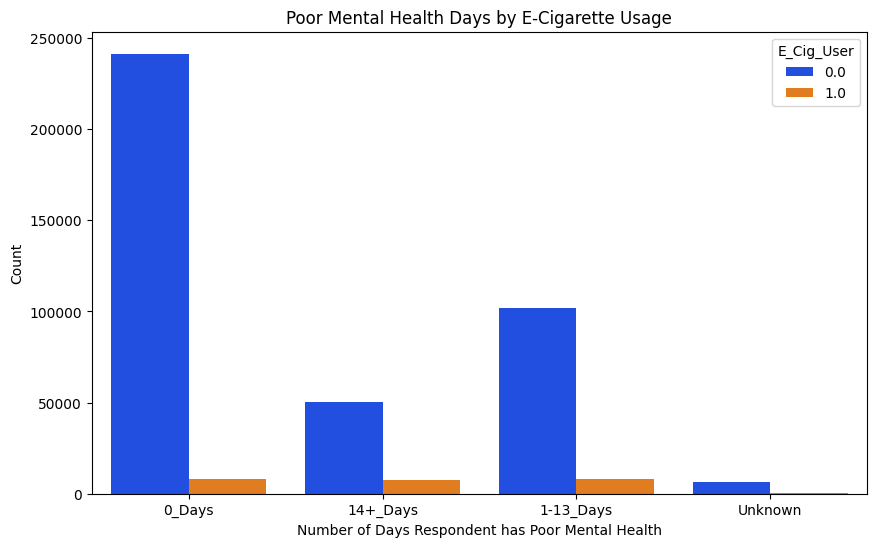

In [132]:
plt.figure(figsize=(10,6))
sns.countplot(data = e_cigarette_data, x = "Days_Poor_Mental_Health", hue = "E_Cig_User", palette="bright")

plt.title("Poor Mental Health Days by E-Cigarette Usage")
plt.xlabel("Number of Days Respondent has Poor Mental Health")
plt.ylabel("Count")

plt.show()

# Graph #2

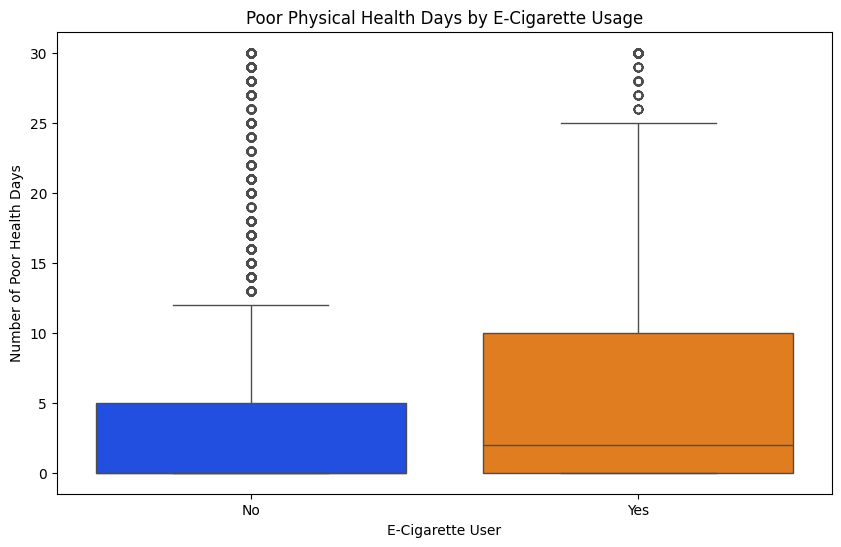

In [133]:
plt.figure(figsize=(10,6))
sns.boxplot(data = e_cigarette_data, x = "E_Cig_User", y = "Number_of_Days_Last_Month_Poor_Health", hue = "E_Cig_User", palette="bright", legend=False)

plt.title("Poor Physical Health Days by E-Cigarette Usage")
plt.xlabel("E-Cigarette User")
plt.ylabel("Number of Poor Health Days")
plt.xticks([0, 1], ["No", "Yes"])

plt.show()

# Graph #3

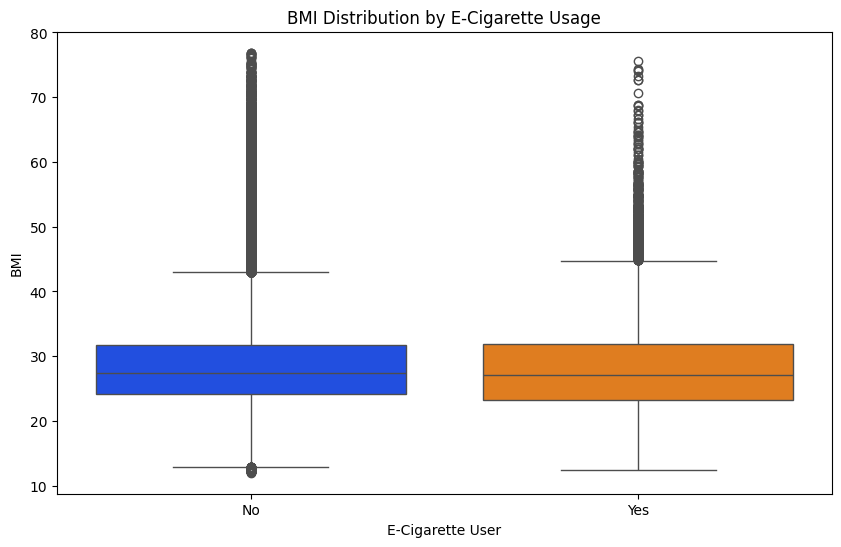

In [134]:
plt.figure(figsize=(10,6))
sns.boxplot(data = e_cigarette_data, x = "E_Cig_User", y = "BMI", hue = "E_Cig_User", palette="bright", legend=False)

plt.title("BMI Distribution by E-Cigarette Usage")
plt.xlabel("E-Cigarette User")
plt.ylabel("BMI")
plt.xticks([0, 1], ["No", "Yes"])

plt.show()

# Graph #4

In [135]:
# https://www.geeksforgeeks.org/data-visualization/normalizing-seaborn-countplot-with-multiple-categorical-variables/
# https://seaborn.pydata.org/tutorial/color_palettes.html
# https://seaborn.pydata.org/generated/seaborn.move_legend.html
# https://seaborn.pydata.org/archive/0.11/generated/seaborn.barplot.html#:~:text=catplot,changing%20bar%20position%20or%20width:

In [136]:
grouped_data_age = e_cigarette_data.groupby(['Age_Category', 'E_Cig_User']).size().reset_index(name = 'counts')
grouped_data_age['total'] = grouped_data_age.groupby('Age_Category')['counts'].transform('sum')
grouped_data_age['proportion'] = grouped_data_age['counts']/grouped_data_age['total']
grouped_data_age

,Age_Category,E_Cig_User,counts,total,proportion
0,Elderly,0.0,197342,200300,0.985232
1,Elderly,1.0,2958,200300,0.014768
2,Middle_Aged,0.0,110122,117145,0.940049
3,Middle_Aged,1.0,7023,117145,0.059951
4,Unknown,0.0,6353,6549,0.970072
5,Unknown,1.0,196,6549,0.029928
6,Young_Adult,0.0,86596,100925,0.858023
7,Young_Adult,1.0,14329,100925,0.141977


In [137]:
# Map 0 and 1 to No and Yes for clarity in the graph
grouped_data_age['E_Cig_User'] = grouped_data_age['E_Cig_User'].map({0.0: "No", 1.0: "Yes"})
grouped_data_age                                                    

,Age_Category,E_Cig_User,counts,total,proportion
0,Elderly,No,197342,200300,0.985232
1,Elderly,Yes,2958,200300,0.014768
2,Middle_Aged,No,110122,117145,0.940049
3,Middle_Aged,Yes,7023,117145,0.059951
4,Unknown,No,6353,6549,0.970072
5,Unknown,Yes,196,6549,0.029928
6,Young_Adult,No,86596,100925,0.858023
7,Young_Adult,Yes,14329,100925,0.141977


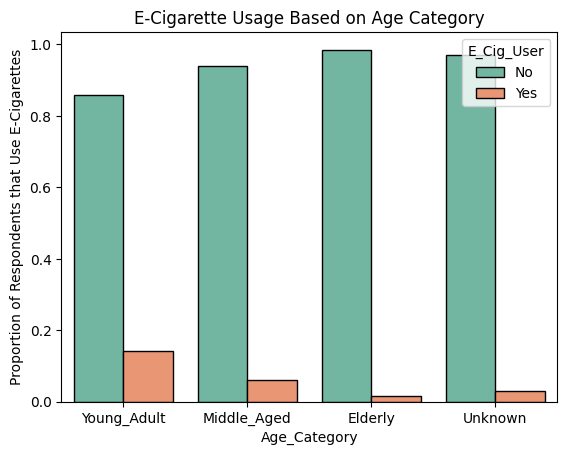

In [138]:
barplot = sns.barplot(x = "Age_Category", y = "proportion", hue = "E_Cig_User", data = grouped_data_age, order = ["Young_Adult", "Middle_Aged", "Elderly", "Unknown"], edgecolor = "black", palette = "Set2")
plt.title("E-Cigarette Usage Based on Age Category")
plt.ylabel("Proportion of Respondents that Use E-Cigarettes")
#sns.move_legend(barplot, "upper left", bbox_to_anchor=(1,1))
plt.show()

# Graph #5

In [139]:
grouped_data_sex = e_cigarette_data.groupby(['Sex', 'E_Cig_User']).size().reset_index(name = 'counts')
grouped_data_sex['total'] = grouped_data_sex.groupby('Sex')['counts'].transform('sum')
grouped_data_sex['proportion'] = grouped_data_sex['counts']/grouped_data_sex['total']
grouped_data_sex

,Sex,E_Cig_User,counts,total,proportion
0,Female,0.0,209855,221439,0.947688
1,Female,1.0,11584,221439,0.052312
2,Male,0.0,190558,203480,0.936495
3,Male,1.0,12922,203480,0.063505


In [140]:
# Map 0 and 1 to No and Yes for clarity in the graph
grouped_data_sex['E_Cig_User'] = grouped_data_sex['E_Cig_User'].map({0.0: "No", 1.0: "Yes"})
grouped_data_sex                                                    

,Sex,E_Cig_User,counts,total,proportion
0,Female,No,209855,221439,0.947688
1,Female,Yes,11584,221439,0.052312
2,Male,No,190558,203480,0.936495
3,Male,Yes,12922,203480,0.063505


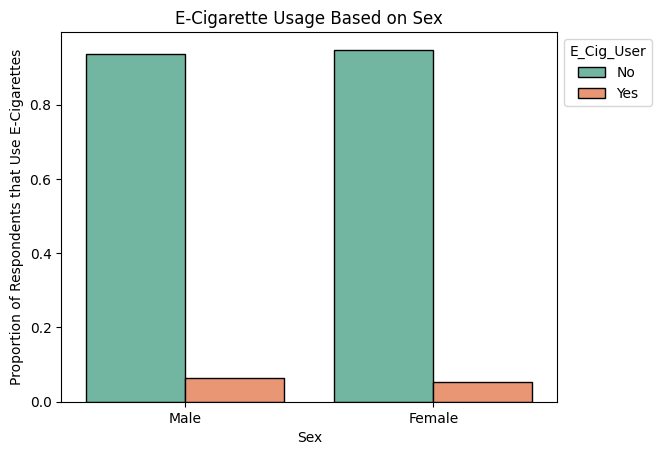

In [141]:
barplot = sns.barplot(x = "Sex", y = "proportion", hue = "E_Cig_User", data = grouped_data_sex, order = ["Male", "Female"], edgecolor = "black", palette = "Set2")
plt.title("E-Cigarette Usage Based on Sex")
plt.ylabel("Proportion of Respondents that Use E-Cigarettes")
sns.move_legend(barplot, "upper left", bbox_to_anchor=(1,1))
plt.show()